In [14]:
"""
=============================================================================
  CDO Synthétique - Pricing Monte Carlo
  Modèle : Intensité stochastique bottom-up avec sauts (Affine Jump-Diffusion)
  Indice : CDX NA IG (N=125 noms)
=============================================================================

"""

import numpy as np
import pandas as pd

# ─────────────────────────────────────────────
# 0. GRAINE ET PARAMÈTRES
# ─────────────────────────────────────────────
rng = np.random.default_rng(seed=42)

# --- Portefeuille ---
N   = 125
R   = 0.40
LGD = 1.0 - R
r   = 0.0014
T   = 5.0

# --- Tranches ---
TRANCHES = [
    (0.00, 0.03),
    (0.03, 0.07),
    (0.07, 0.15),
    (0.15, 1.00),
]
TRANCHE_NAMES = ["Equity [0,3%]", "Mezz I [3,7%]", "Mezz II [7,15%]", "Senior [15,100%]"]

# --- Processus systémique ---
kappa    = 0.6
theta    = 0.02
sigma    = 0.14
lambda_J = 0.05
mu_jump  = 0.10
lam0     = 0.02

# --- Idiosyncratique ---
beta     = 1.0
lam_idio = 0.001

# --- Discrétisation ---
dt      = 1.0 / 252
n_steps = int(T / dt)
M       = 10_000

# --- Dates de paiement ---
pay_dates = np.arange(0.25, T + 1e-10, 0.25)
n_pay = len(pay_dates)

pay_idx = np.round(pay_dates / dt).astype(int) - 1
pay_idx = np.clip(pay_idx, 0, n_steps - 1)

print("=" * 60)
print("  CDO SYNTHÉTIQUE – MONTE CARLO")
print(f"  M={M:,} scénarios | N={N} noms | T={T} ans")
print("=" * 60)

# 1. SIMULATION DU FACTEUR SYSTÉMIQUE
# ─────────────────────────────────────────────

lam_syst = np.full(M, lam0)
int_lam_syst_pay = np.zeros((M, n_pay))
cum_integral = np.zeros(M)

pay_counter = 0


for step in range(n_steps):
    Z = rng.standard_normal(M)

    lam_plus = np.maximum(lam_syst, 0.0)

    n_jumps = rng.poisson(lambda_J * dt, size=M)

    jump_sizes = np.where(
        n_jumps > 0,
        rng.gamma(shape=n_jumps + 1e-10, scale=mu_jump),
        0.0
    )
    jump_sizes = np.where(n_jumps == 0, 0.0, jump_sizes)

    lam_syst = (
        lam_plus
        + kappa * (theta - lam_plus) * dt
        + sigma * np.sqrt(lam_plus * dt) * Z
        + jump_sizes
    )

    lam_syst = np.maximum(lam_syst, 0.0)

    cum_integral += lam_syst * dt

    if pay_counter < n_pay and step == pay_idx[pay_counter]:
        int_lam_syst_pay[:, pay_counter] = cum_integral
        pay_counter += 1

print(f"   λ_syst final moyen: {lam_syst.mean():.5f}")


# 2. INTENSITÉ INTÉGRÉE
# ─────────────────────────────────────────────


idio_contrib = lam_idio * pay_dates
Lambda_total = int_lam_syst_pay + idio_contrib[np.newaxis, :]


# 3. DÉFAUTS
# ─────────────────────────────────────────────


E = rng.exponential(scale=1.0, size=(M, N))

defaulted = Lambda_total[:, :, np.newaxis] > E[:, np.newaxis, :]


# 4. PERTES
# ─────────────────────────────────────────────


n_def = defaulted.sum(axis=2)
L_port = n_def * LGD / N

n_tranches = len(TRANCHES)
ETL = np.zeros((n_tranches, n_pay))

for j, (A, D) in enumerate(TRANCHES):
    width = D - A
    L_tr = (np.minimum(L_port, D) - A).clip(min=0.0) / width
    ETL[j, :] = L_tr.mean(axis=0)


# 5. SPREADS
# ─────────────────────────────────────────────

disc = np.exp(-r * pay_dates)
dt_pay = np.diff(np.concatenate([[0.0], pay_dates]))

ETL_with_0 = np.hstack([np.zeros((n_tranches, 1)), ETL])
dETL = np.diff(ETL_with_0, axis=1)

spreads_bps = []
results = []

for j in range(n_tranches):
    A, D = TRANCHES[j]

    PL = np.sum(disc * dETL[j, :])
    RPL = np.sum(disc * dt_pay * (1.0 - ETL[j, :]))

    s_star = (PL / RPL) * 10_000 if RPL > 1e-12 else np.nan

    spreads_bps.append(s_star)
    results.append({
        "Tranche": TRANCHE_NAMES[j],
        "Spread (bps)": f"{s_star:.2f}",
    })


# 6. RÉSULTATS
# ─────────────────────────────────────────────
df = pd.DataFrame(results)

print("\n" + "=" * 60)
print("  SPREADS PAR TRANCHE")
print("=" * 60)
print(df.to_string(index=False))
print("=" * 60)

print("\n--- Diagnostics ---")
print(f"Perte moyenne: {L_port[:, -1].mean():.4%}")
print(f"Nb moyen de défauts: {n_def[:, -1].mean():.2f}")
print(f"ETL Equity: {ETL[0, -1]:.4%}")
print(f"ETL Senior: {ETL[3, -1]:.4%}")

  CDO SYNTHÉTIQUE – MONTE CARLO
  M=10,000 scénarios | N=125 noms | T=5.0 ans
   λ_syst final moyen: 0.02802

  SPREADS PAR TRANCHE
         Tranche Spread (bps)
   Equity [0,3%]      6285.66
   Mezz I [3,7%]      1676.46
 Mezz II [7,15%]       396.36
Senior [15,100%]         9.07

--- Diagnostics ---
Perte moyenne: 7.2119%
Nb moyen de défauts: 15.02
ETL Equity: 95.5532%
ETL Senior: 0.4539%


λ (intensité marginale) = 0.006167  (61.67 bps)

  Equity [0,3%]
    Spread cible   :  6285.66 bps
    Intervalle LHP : [54.77, 1786.12] bps
   Hors frontière LHP (AU-DESSUS) — pas de ρ implicite

  Mezz I [3,7%]
    Spread cible   :  1676.46 bps
    Intervalle LHP : [0.00, 232.13] bps
   Hors frontière LHP (AU-DESSUS) — pas de ρ implicite

  Mezz II [7,15%]
    Spread cible   :   396.36 bps
    Intervalle LHP : [0.00, 110.86] bps
   Hors frontière LHP (AU-DESSUS) — pas de ρ implicite

  Senior [15,100%]
    Spread cible   :     9.07 bps
    Intervalle LHP : [0.00, 28.62] bps
    ρ* implicite : 0.6492  (64.92%)

  TABLEAU FINAL – CORRÉLATION IMPLICITE vs FRONTIÈRE DU MODÈLE LHP
         Tranche Spread cible (bps) Min LHP (bps) Max LHP (bps) Dans l’intervalle ?     ρ* implicite
   Equity [0,3%]            6285.66         54.77       1786.12                 Non —  (hors modèle)
   Mezz I [3,7%]            1676.46          0.00        232.13                 Non —  (hors modèle)
 Mezz II [

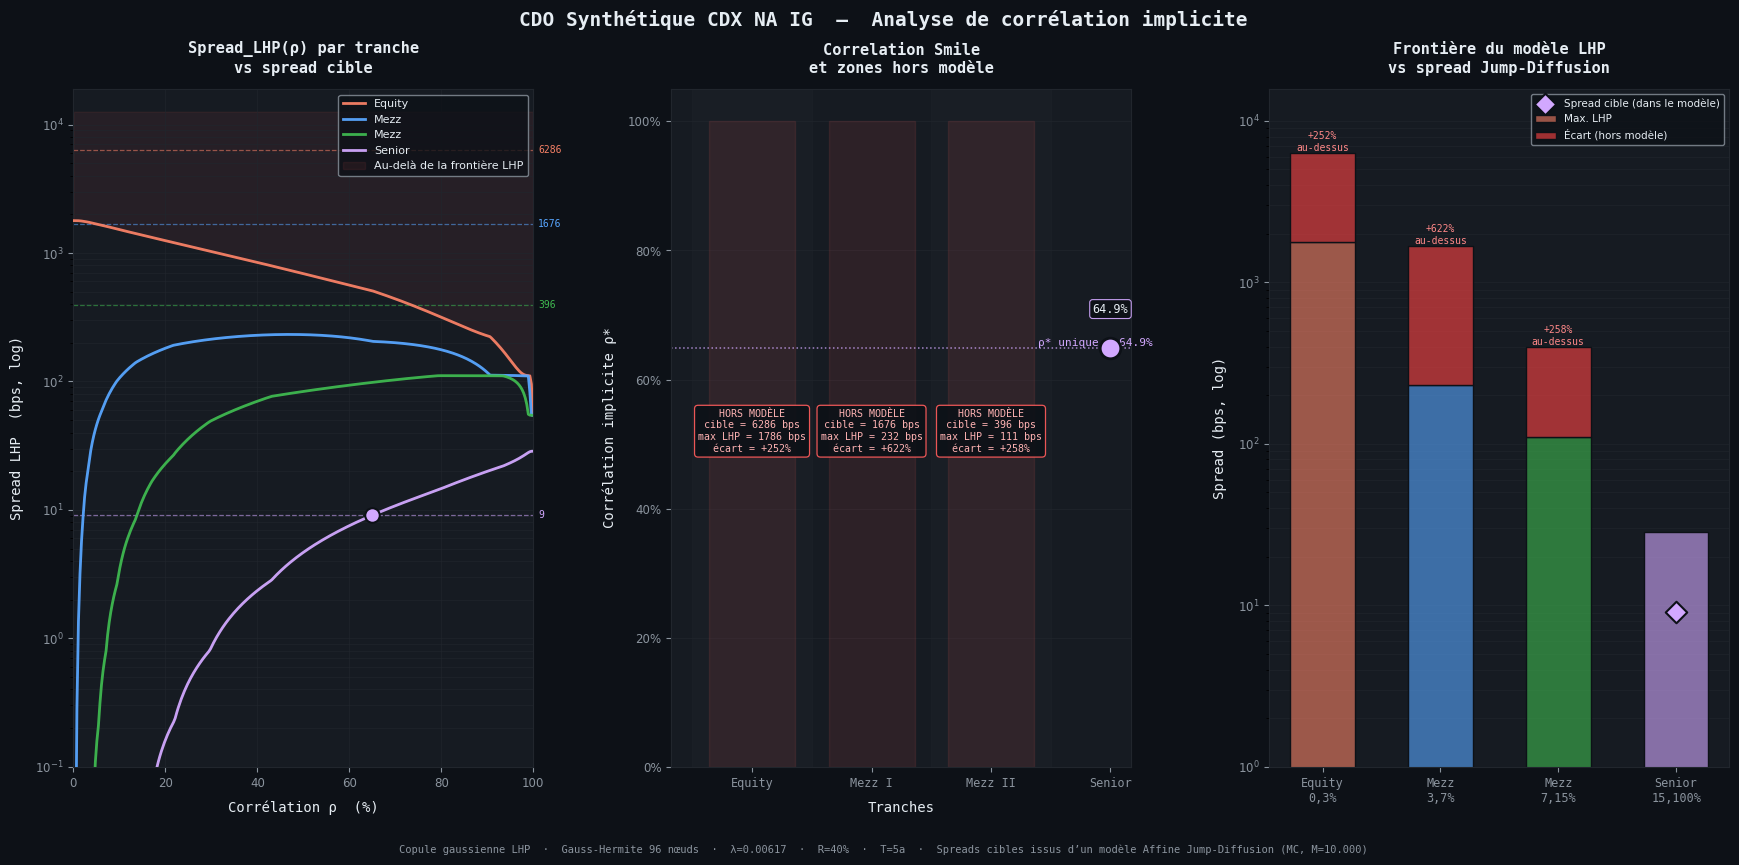

In [13]:
"""
=============================================================================
  CDO SYNTHÉTIQUE – CORRÉLATION IMPLICITE & CORRELATION SMILE
  Modèle : Copule gaussienne + LHP (Large Homogeneous Portfolio)
  Méthode : Compound Correlation + Base Correlation + diagnostic de modèle
=============================================================================
Le script :
  1. calcule les spreads LHP en fonction de ρ ∈ [0,1] pour chaque tranche ;
  2. vérifie si le spread cible appartient au domaine atteignable du modèle ;
  3. calcule la corrélation implicite lorsque cela est possible ;
  4. trace le correlation smile et un diagnostic de modèle.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import norm
from scipy.optimize import brentq
from scipy.special import roots_hermite


# 0. PARAMÈTRES
# ─────────────────────────────────────────────────────────────────
R   = 0.40
LGD = 1.0 - R
r   = 0.0014
T   = 5.0

# λ = spread_indice / LGD  (spread moyen CDX IG ≈ 37 bps)
lam = 0.0037 / LGD
print(f"λ (intensité marginale) = {lam:.6f}  ({lam*10_000:.2f} bps)")

pay_dates = np.arange(0.25, T + 1e-10, 0.25)
disc      = np.exp(-r * pay_dates)
dt_pay    = np.diff(np.concatenate([[0.0], pay_dates]))

TRANCHES       = [(0.00, 0.03), (0.03, 0.07), (0.07, 0.15), (0.15, 1.00)]
TRANCHE_NAMES  = ["Equity [0,3%]", "Mezz I [3,7%]", "Mezz II [7,15%]", "Senior [15,100%]"]
SPREADS_TARGET = np.array([6285.66, 1676.46, 396.36, 9.07])


# 1. QUADRATURE DE GAUSS-HERMITE
# ─────────────────────────────────────────────────────────────────
N_QUAD = 96
x_herm, w_herm = roots_hermite(N_QUAD)
m_nodes = np.sqrt(2.0) * x_herm
w_gauss = w_herm / np.sqrt(np.pi)


# 2. FONCTIONS LHP
# ─────────────────────────────────────────────────────────────────

def etl_tranche(rho, t, A, D):
    """ETL de la tranche [A,D] via quadrature de Gauss-Hermite."""
    p    = 1.0 - np.exp(-lam * t)
    zbar = norm.ppf(p)
    arg  = (zbar - np.sqrt(rho) * m_nodes) / np.sqrt(max(1.0 - rho, 1e-12))
    L    = LGD * norm.cdf(arg)
    width = D - A
    loss  = np.clip(L - A, 0.0, width) / width
    return np.dot(w_gauss, loss)

def spread_lhp(rho, A, D):
    """Spread juste (en bps) de la tranche [A,D] pour une corrélation ρ donnée."""
    etl  = np.array([etl_tranche(rho, t, A, D) for t in pay_dates])
    detl = np.diff(np.concatenate([[0.0], etl]))
    PL   = np.sum(disc * detl)
    RPL  = np.sum(disc * dt_pay * (1.0 - etl))
    return (PL / RPL * 10_000.0) if RPL > 1e-14 else np.nan


# 3. BALAYAGE : SPREAD LHP vs ρ
# ─────────────────────────────────────────────────────────────────

rho_scan = np.linspace(0.001, 0.999, 300)
spread_curves = []
for (A, D) in TRANCHES:
    curve = np.array([spread_lhp(rho, A, D) for rho in rho_scan])
    spread_curves.append(curve)


# 4. CORRÉLATION IMPLICITE (COMPOUND) via BRENTQ
# ─────────────────────────────────────────────────────────────────


implied_rho = []
in_range    = []
s_min_lhp   = []
s_max_lhp   = []

for j, ((A, D), name, s_tgt, curve) in enumerate(
    zip(TRANCHES, TRANCHE_NAMES, SPREADS_TARGET, spread_curves)
):
    s_min = np.nanmin(curve)
    s_max = np.nanmax(curve)
    s_min_lhp.append(s_min)
    s_max_lhp.append(s_max)

    within = (s_min <= s_tgt <= s_max)
    in_range.append(within)

    print(f"\n  {name}")
    print(f"    Spread cible   : {s_tgt:8.2f} bps")
    print(f"    Intervalle LHP : [{s_min:.2f}, {s_max:.2f}] bps")

    if within:
        def f_obj(rho, A=A, D=D, s=s_tgt):
            return spread_lhp(rho, A, D) - s

        f_scan = curve - s_tgt
        cidxs = np.where(np.diff(np.sign(f_scan)))[0]

        rho_star = brentq(
            f_obj,
            rho_scan[cidxs[0]],
            rho_scan[cidxs[0] + 1],
            xtol=1e-8,
            maxiter=300
        )
        print(f"    ρ* implicite : {rho_star:.4f}  ({rho_star*100:.2f}%)")
    else:
        rho_star = np.nan
        direction = "AU-DESSUS" if s_tgt > s_max else "EN DESSOUS"
        print(f"   Hors frontière LHP ({direction}) — pas de ρ implicite")

    implied_rho.append(rho_star)


# 5. TABLEAU DE RÉSULTATS
# ─────────────────────────────────────────────────────────────────
df = pd.DataFrame({
    "Tranche"             : TRANCHE_NAMES,
    "Spread cible (bps)"  : [f"{s:.2f}" for s in SPREADS_TARGET],
    "Min LHP (bps)"       : [f"{s:.2f}" for s in s_min_lhp],
    "Max LHP (bps)"       : [f"{s:.2f}" for s in s_max_lhp],
    "Dans l’intervalle ?" : ["Oui" if v else " Non" for v in in_range],
    "ρ* implicite"        : [
        f"{rho:.4f}  ({rho*100:.1f}%)" if not np.isnan(rho)
        else "—  (hors modèle)"
        for rho in implied_rho
    ],
})

print("\n" + "=" * 90)
print("  TABLEAU FINAL – CORRÉLATION IMPLICITE vs FRONTIÈRE DU MODÈLE LHP")
print("=" * 90)
print(df.to_string(index=False))
print("=" * 90)



# 6. GRAPHIQUE
# ─────────────────────────────────────────────────────────────────


BG_DARK  = "#0D1117"
BG_PANEL = "#161B22"
GRID_COL = "#21262D"
TEXT_COL = "#E6EDF3"
MUTED    = "#8B949E"
RED_WARN = "#FF5C5C"
COLORS   = ["#F78166", "#58A6FF", "#3FB950", "#D2A8FF"]

fig = plt.figure(figsize=(18, 8.8), facecolor=BG_DARK)
gs  = fig.add_gridspec(
    1, 3,
    left=0.05, right=0.97,
    top=0.88, bottom=0.11,
    wspace=0.30
)

# ── Painel A : Spread_LHP(ρ) por tranche ────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor(BG_PANEL)

for j, ((A, D), name, curve, s_tgt, color) in enumerate(
    zip(TRANCHES, TRANCHE_NAMES, spread_curves, SPREADS_TARGET, COLORS)
):
    ax1.semilogy(
        rho_scan * 100,
        curve,
        color=color,
        lw=2.0,
        label=f"{name.split(' ')[0]}",
        alpha=0.95,
        zorder=3
    )

    ax1.axhline(s_tgt, color=color, lw=0.9, ls="--", alpha=0.55)

    ax1.text(
        101, s_tgt, f"{s_tgt:.0f}",
        va="center", ha="left",
        fontsize=7, color=color, fontfamily="monospace"
    )

    if not np.isnan(implied_rho[j]):
        ax1.scatter(
            [implied_rho[j] * 100], [s_tgt],
            s=110, color=color, zorder=6,
            edgecolors=BG_DARK, linewidths=1.5
        )

max_curve = np.max([curve for curve in spread_curves], axis=0)
ax1.fill_between(
    rho_scan * 100,
    max_curve,
    np.full_like(rho_scan, max(SPREADS_TARGET) * 2),
    alpha=0.07, color=RED_WARN,
    label="Au-delà de la frontière LHP"
)

ax1.set_xlabel(
    "Corrélation ρ  (%)",
    fontsize=10, color=TEXT_COL,
    labelpad=8, fontfamily="monospace"
)
ax1.set_ylabel(
    "Spread LHP  (bps, log)",
    fontsize=10, color=TEXT_COL,
    labelpad=8, fontfamily="monospace"
)
ax1.set_title(
    "Spread_LHP(ρ) par tranche\nvs spread cible",
    fontsize=11, color=TEXT_COL, fontweight="bold",
    fontfamily="monospace", pad=12
)
ax1.set_xlim(0, 100)
ax1.set_ylim(0.1, max(SPREADS_TARGET) * 3)
ax1.tick_params(colors=MUTED, labelsize=8.5)
ax1.spines[:].set_color(GRID_COL)
ax1.grid(True, color=GRID_COL, lw=0.6, alpha=0.75, which="both")
ax1.legend(
    fontsize=8,
    facecolor=BG_DARK,
    edgecolor=MUTED,
    labelcolor=TEXT_COL,
    loc="upper right"
)

# ── Painel B : Correlation Smile (versão melhorada) ─────────────
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor(BG_PANEL)

x_pos = np.arange(len(TRANCHES))
rho_pct = np.array(implied_rho) * 100.0
valid = ~np.isnan(rho_pct)

# Fundo alternado por tranche para leitura
for j in range(len(TRANCHES)):
    if j % 2 == 0:
        ax2.axvspan(j - 0.5, j + 0.5, color="#FFFFFF", alpha=0.015, zorder=0)

# Linha-guia horizontal
for y in [0, 20, 40, 60, 80, 100]:
    ax2.axhline(y, color=GRID_COL, lw=0.7, alpha=0.7, zorder=0)

# Colunas de fundo para "hors modèle"
for j in range(len(TRANCHES)):
    if not valid[j]:
        ax2.bar(
            x_pos[j], 100,
            width=0.72,
            color=RED_WARN,
            alpha=0.10,
            edgecolor=RED_WARN,
            linewidth=1.0,
            zorder=1
        )

        gap_pct_j = (SPREADS_TARGET[j] / s_max_lhp[j] - 1.0) * 100.0 if s_max_lhp[j] > 0 else np.nan
        txt = (
            "HORS MODÈLE\n"
            f"cible = {SPREADS_TARGET[j]:.0f} bps\n"
            f"max LHP = {s_max_lhp[j]:.0f} bps"
        )
        if np.isfinite(gap_pct_j):
            txt += f"\nécart = +{gap_pct_j:.0f}%"

        ax2.text(
            x_pos[j], 52, txt,
            ha="center", va="center",
            fontsize=7.2, color="#FFB3B3",
            fontfamily="monospace",
            bbox=dict(
                boxstyle="round,pad=0.35",
                fc=BG_DARK, ec=RED_WARN, alpha=0.92, lw=0.9
            ),
            zorder=4
        )

# Linha ligando apenas os pontos válidos
if valid.sum() >= 2:
    ax2.plot(
        x_pos[valid], rho_pct[valid],
        color="#58A6FF", lw=1.8, ls="--", alpha=0.8, zorder=3
    )

# Pontos válidos
for j in range(len(TRANCHES)):
    if valid[j]:
        ax2.scatter(
            x_pos[j], rho_pct[j],
            s=220, color=COLORS[j],
            edgecolors=BG_DARK, linewidths=2.0,
            zorder=5
        )
        ax2.text(
            x_pos[j], rho_pct[j] + 5.0,
            f"{rho_pct[j]:.1f}%",
            ha="center", va="bottom",
            fontsize=8.5, color=TEXT_COL,
            fontfamily="monospace",
            bbox=dict(
                boxstyle="round,pad=0.25",
                fc=BG_DARK, ec=COLORS[j], alpha=0.92, lw=0.8
            ),
            zorder=6
        )

# Se só houver 1 ponto válido, destacar melhor
if valid.sum() == 1:
    j = np.where(valid)[0][0]
    ax2.axhline(rho_pct[j], color=COLORS[j], lw=1.1, ls=":", alpha=0.75, zorder=2)
    ax2.text(
        3.35, rho_pct[j],
        f"ρ* unique = {rho_pct[j]:.1f}%",
        ha="right", va="bottom",
        fontsize=8, color=COLORS[j],
        fontfamily="monospace"
    )

ax2.set_xticks(x_pos)
ax2.set_xticklabels(
    ["Equity", "Mezz I", "Mezz II", "Senior"],
    fontsize=8.5, color=MUTED, fontfamily="monospace"
)
ax2.set_ylim(0, 105)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax2.set_ylabel(
    "Corrélation implicite ρ*",
    fontsize=10, color=TEXT_COL,
    labelpad=8, fontfamily="monospace"
)
ax2.set_xlabel(
    "Tranches",
    fontsize=10, color=TEXT_COL,
    labelpad=8, fontfamily="monospace"
)
ax2.set_title(
    "Correlation Smile\net zones hors modèle",
    fontsize=11, color=TEXT_COL, fontweight="bold",
    fontfamily="monospace", pad=12
)
ax2.tick_params(colors=MUTED, labelsize=8.5)
ax2.spines[:].set_color(GRID_COL)
ax2.grid(False)

# ── Painel C : Diagnostic — écart du modèle ─────────────────────
ax3 = fig.add_subplot(gs[2])
ax3.set_facecolor(BG_PANEL)

labels = [
    n.split(" ")[0] + "\n" + n.split("[")[1].rstrip("]")
    for n in TRANCHE_NAMES
]
x_pos_c   = np.arange(4)
s_max_arr = np.array(s_max_lhp)
s_tgt_arr = SPREADS_TARGET
gap       = s_tgt_arr - s_max_arr
gap_pct   = gap / s_max_arr * 100

ax3.bar(
    x_pos_c, s_max_arr,
    color=[c + "99" for c in COLORS],
    width=0.55,
    label="Max. LHP",
    edgecolor=BG_DARK,
    zorder=2
)

for j in range(4):
    if gap[j] > 0:
        ax3.bar(
            x_pos_c[j], gap[j],
            bottom=s_max_arr[j],
            color="#FF444499",
            width=0.55,
            edgecolor=BG_DARK,
            zorder=3,
            label="Écart (hors modèle)" if j == 0 else ""
        )
        ax3.text(
            x_pos_c[j], s_tgt_arr[j] + s_max_arr[j] * 0.03,
            f"+{gap_pct[j]:.0f}%\nau-dessus",
            ha="center", va="bottom",
            fontsize=7, color="#FF8888",
            fontfamily="monospace"
        )
    else:
        ax3.scatter(
            [x_pos_c[j]], [s_tgt_arr[j]],
            s=120, color=COLORS[j],
            zorder=6, edgecolors=BG_DARK, linewidths=1.5,
            marker="D",
            label="Spread cible (dans le modèle)" if j == 3 else ""
        )

ax3.set_xticks(x_pos_c)
ax3.set_xticklabels(labels, fontsize=7.5, color=MUTED, fontfamily="monospace")
ax3.set_ylabel(
    "Spread (bps, log)",
    fontsize=10, color=TEXT_COL,
    labelpad=8, fontfamily="monospace"
)
ax3.set_title(
    "Frontière du modèle LHP\nvs spread Jump-Diffusion",
    fontsize=11, color=TEXT_COL, fontweight="bold",
    fontfamily="monospace", pad=12
)
ax3.set_yscale("log")
ax3.set_ylim(1, max(SPREADS_TARGET) * 2.5)
ax3.tick_params(colors=MUTED, labelsize=8.5)
ax3.spines[:].set_color(GRID_COL)
ax3.grid(True, axis="y", color=GRID_COL, lw=0.6, alpha=0.75, which="both")
ax3.legend(
    fontsize=7.5,
    facecolor=BG_DARK,
    edgecolor=MUTED,
    labelcolor=TEXT_COL,
    loc="upper right"
)

# Bas de figure
fig.text(
    0.5, 0.012,
    f"Copule gaussienne LHP  ·  Gauss-Hermite {N_QUAD} nœuds  ·  "
    f"λ={lam:.5f}  ·  R={R:.0%}  ·  T={T:.0f}a  ·  "
    "Spreads cibles issus d’un modèle Affine Jump-Diffusion (MC, M=10.000)",
    ha="center",
    fontsize=7.5,
    color=MUTED,
    fontfamily="monospace"
)

fig.suptitle(
    "CDO Synthétique CDX NA IG  —  Analyse de corrélation implicite",
    fontsize=14,
    color=TEXT_COL,
    fontweight="bold",
    fontfamily="monospace",
    y=0.97
)

plt.show()